In [125]:
import gauss_decomp as gdc
import numpy as np
from astropy.io import fits
import os
import matplotlib.pyplot as plt
from matplotlib import colors
from iris_lmsalpy import extract_irisL2data as ei
from scipy.io import readsav
from iris_lmsalpy import saveall as sv
from scipy.stats import spearmanr
from matplotlib import colors
from mpl_toolkits.axes_grid1 import make_axes_locatable
import glob
import umap
import hdbscan
from sklearn.preprocessing import StandardScaler
from matplotlib.lines import Line2D

In [4]:
os.environ['path']= '/Users/souvikb/various_analysis/GaussSep/'
os.environ['results_dir'] = '/Users/souvikb/various_analysis/GaussSep/Results/'
b_vec_path = '/Users/souvikb/various_analysis/GaussSep/bose_codes/plage_heating/b_vec_data'
os.environ['IDL_saved_arrays'] = '/Users/souvikb/various_analysis/GaussSep/bose_codes/alignment_saved_files/20170305_164005/'
os.environ['iris2_atmos_path'] = '/Users/souvikb/various_analysis/iris2_p/l2_iris_data/Photospheric_imprints_IRIS_l2_data/2017_03_05/'

In [5]:
co_aligned_arrays = np.load(b_vec_path+'/aligned_iris_sot_upper_chromos.npz')
IRL = co_aligned_arrays['IRL']
Temp = co_aligned_arrays['Temp']
Ne = co_aligned_arrays['Ne']
E_dens_gt = co_aligned_arrays['E_dens_gt']
E_dens_lt = co_aligned_arrays['E_dens_lt']
Bz = co_aligned_arrays['Bz_align']
Turb = co_aligned_arrays['Turb']
Bzgt_obs = co_aligned_arrays['Bgtz_obs_aligned']

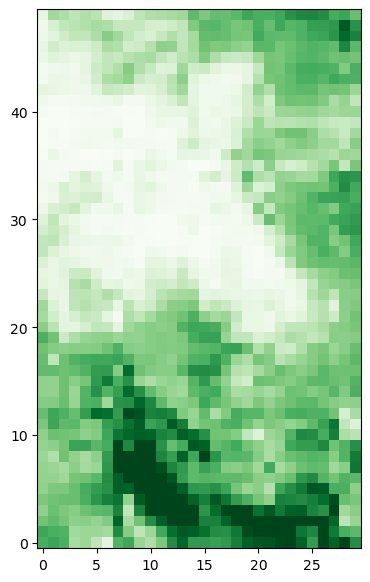

In [6]:
plt.figure(figsize=(7,7))
plt.imshow(Turb[180:230,65:95]**2, origin='lower', vmin=0, vmax=100, interpolation='none',cmap='Greens')

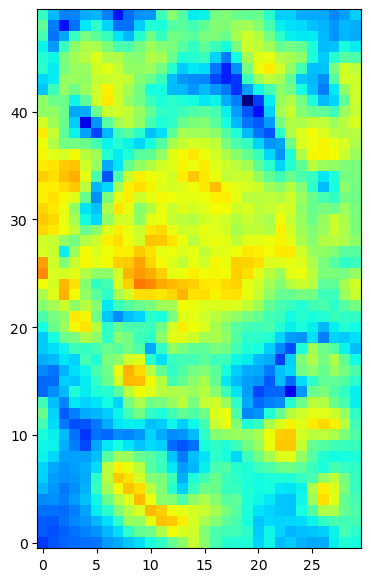

In [7]:
plt.figure(figsize=(7,7))
plt.imshow(E_dens_gt[180:230,65:95], origin='lower',norm=colors.PowerNorm(0.3,vmax=2.e3),cmap='jet')

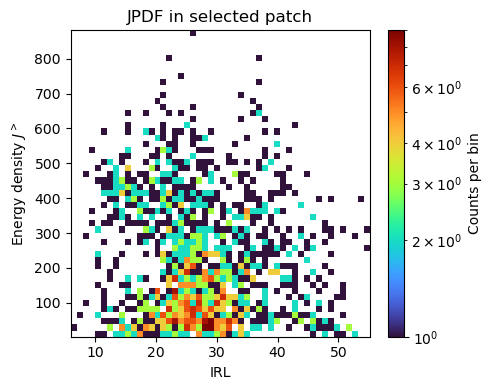

In [8]:
sub_IRL = IRL[180:230, 65:95].ravel()
sub_E = E_dens_gt[180:230, 65:95].ravel()
sub_Bz = np.abs(Bz[180:230, 65:95]).ravel()

mask = np.isfinite(sub_IRL) & np.isfinite(sub_E) & (sub_E > 0)

plt.figure(figsize=(5, 4))
h = plt.hist2d(
    sub_IRL[mask],
    sub_E[mask],
    bins=50,
    cmap='turbo',
    norm=colors.LogNorm()
)
plt.xlabel('IRL')
plt.ylabel(r'Energy density $J^{>}$')
plt.title('JPDF in selected patch')
plt.colorbar(h[3], label='Counts per bin')
plt.tight_layout()


In [9]:
from scipy.stats import pearsonr, spearmanr
spearmanr(sub_IRL, sub_E)

SignificanceResult(statistic=-0.09867245833977473, pvalue=0.00012933258168707596)

## Clustering using **HDBSCAN**

In [11]:
%%time
abs_B = np.abs(Bz)
space_weight = 1.
min_cluster_size = 250
min_samples=10
# Any form of clustering can be done only in the feature space. So here the feature is |B| for each X and Y
y_coords, x_coords = np.indices(abs_B.shape) ## BEcause we need the position of elements of the 2D array not just regular indices
X = np.column_stack([
    x_coords.ravel().astype(float),
    y_coords.ravel().astype(float),
    abs_B.ravel().astype(float),
])

# Scale features but allow a tunable spatial weight
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # mean=0, std=1 along each feature
print(X.shape, X_scaled.shape)

X_scaled[:, 0] *= space_weight
X_scaled[:, 1] *= space_weight

# Run HDBSCAN
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=min_cluster_size,
    cluster_selection_method='leaf',
    cluster_selection_epsilon=0.03,
    min_samples=min_samples,
    metric='euclidean',
    core_dist_n_jobs=12
)
labels = clusterer.fit_predict(X_scaled)
labels_2d = labels.reshape(abs_B.shape)

(153439, 3) (153439, 3)


/Users/souvikb/miniforge3/envs/gauss_decomp/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/souvikb/miniforge3/envs/gauss_decomp/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


CPU times: user 2.76 s, sys: 216 ms, total: 2.97 s
Wall time: 5.52 s


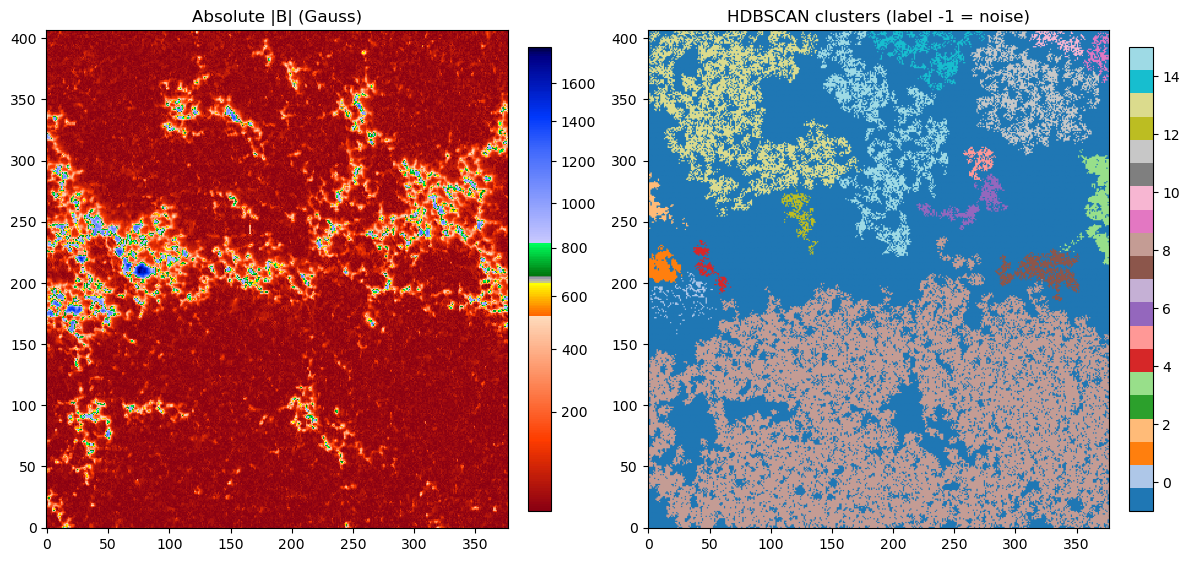

In [12]:
# Visualization
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].set_title("Absolute |B| (Gauss)")
im0 = ax[0].imshow(abs_B, origin='lower', cmap='hmimag', interpolation='none',norm=colors.PowerNorm(0.7))
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

ax[1].set_title("HDBSCAN clusters (label -1 = noise)")
# Use a cyclical colormap for clusters (tab20 will repeat for many clusters)
im1 = ax[1].imshow(labels_2d, origin='lower', cmap='tab20')
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## Forced Clustering by |B| strengths


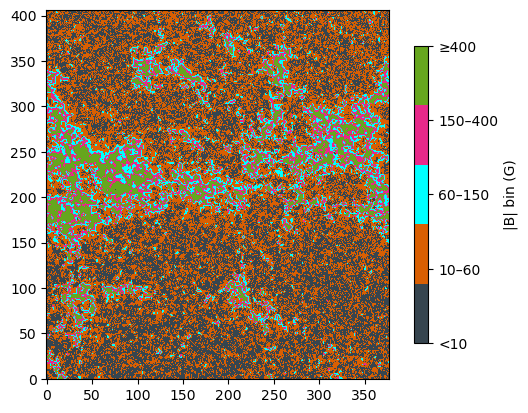

In [13]:
b_bins = [(10, 60), (60, 150), (150, 400), (400, np.round(np.max(abs_B)))]
import matplotlib
segment_ids = np.zeros_like(abs_B, dtype=int)
segment_ids[np.where((abs_B <= b_bins[0][0]))] = -1
segment_ids[np.where((abs_B >= b_bins[0][0]) & (abs_B < b_bins[0][1]))] =1
segment_ids[np.where((abs_B >= b_bins[1][0]) & (abs_B < b_bins[1][1]))] =2
segment_ids[np.where((abs_B >= b_bins[2][0]) & (abs_B < b_bins[2][1]))] =3
segment_ids[np.where((abs_B >= b_bins[3][0]) & (abs_B < b_bins[3][1]))] =4
# b_bins[0][0]
# np.where((np.abs(B_z_cropped) >= b_bins[0][0]) & (np.abs(B_z_cropped) < b_bins[0][1]))
# plt.imshow(np.where((np.abs(B_z_cropped) >= b_bins[0][0]) & (np.abs(B_z_cropped) < b_bins[0][1]),1.0, 0),origin='lower')
# colors = ["#FFFFFF", "#d62728", "#2ca02c", "#9467bd", "#ff7f0e"]  # distinct, colorblind-friendly
colors1 = ["#36454F", "#d95f02", "#00FFFF", "#e7298a", "#66a61e"]
cmap = matplotlib.colors.ListedColormap(colors1)

plt.imshow(segment_ids[:,:], cmap=cmap, vmin=0, vmax=4, origin='lower', interpolation='none')
cbar = plt.colorbar(ticks=range(5), fraction=0.03)
cbar.ax.set_yticklabels(["<10", "10–60", "60–150", "150–400", "≥400"])
cbar.set_label("|B| bin (G)")
plt.show()


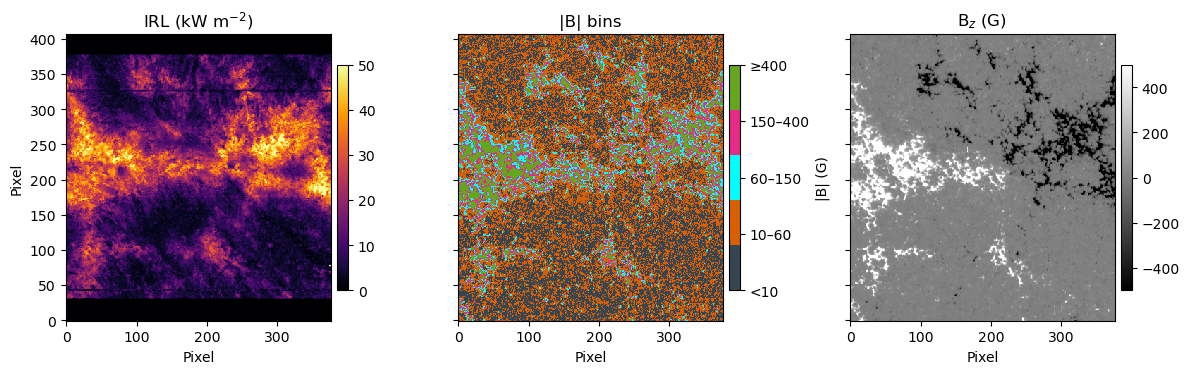

In [252]:
import matplotlib
b_bins = [(10, 60), (60, 150), (150, 400), (400, np.round(np.max(abs_B)))]
segment_ids = np.zeros_like(abs_B, dtype=int)
segment_ids[np.where((abs_B <= b_bins[0][0]))] = -1
segment_ids[np.where((abs_B >= b_bins[0][0]) & (abs_B < b_bins[0][1]))] =1
segment_ids[np.where((abs_B >= b_bins[1][0]) & (abs_B < b_bins[1][1]))] =2
segment_ids[np.where((abs_B >= b_bins[2][0]) & (abs_B < b_bins[2][1]))] =3
segment_ids[np.where((abs_B >= b_bins[3][0]) & (abs_B < b_bins[3][1]))] =4
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 4.), sharex=True, sharey=True)

# 1) IRL (saturate 0–50)
im0 = ax[0].imshow(IRL, origin='lower', cmap='inferno', vmin=0, vmax=50, interpolation='none')
ax[0].set_title('IRL (kW m$^{-2}$)')
plt.colorbar(im0, ax=ax[0], fraction=0.04, pad=0.02)

# 2) segment_ids (inferno)
# map -1 (|B|<10) to 0 for plotting 5 clean levels 0..4
# seg_plot = np.where(segment_ids == -1, 0, segment_ids)
im1 = ax[1].imshow(segment_ids[:,:], cmap=cmap, vmin=0, vmax=4, origin='lower', interpolation='none')
ax[1].set_title('|B| bins')
cbar1 = plt.colorbar(im1, ax=ax[1], ticks=[0,1,2,3,4], fraction=0.04, pad=0.02)
cbar1.ax.set_yticklabels(['<10', '10–60', '60–150', '150–400', '≥400'])
cbar1.set_label('|B| (G)')

# 3) Bz in gray, clipped to [-500, 500] G
im2 = ax[2].imshow(Bz, origin='lower', cmap='gray', vmin=-500, vmax=500, interpolation='none')
ax[2].set_title(r'B$_z$ (G)')
plt.colorbar(im2, ax=ax[2], fraction=0.04, pad=0.02)

for a in ax:
    a.set_xlabel('Pixel')
ax[0].set_ylabel('Pixel')

plt.tight_layout()
plt.savefig(os.path.join(os.environ['results_dir'], 'IRL_Bz_Bbins.png'), dpi=300, bbox_inches='tight')


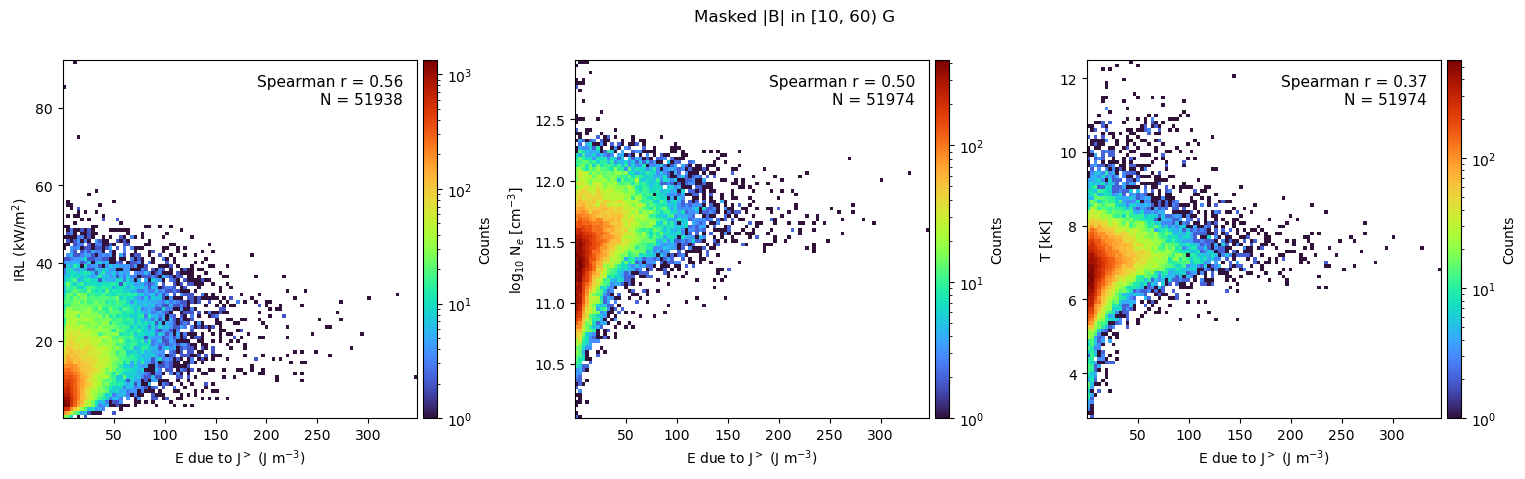

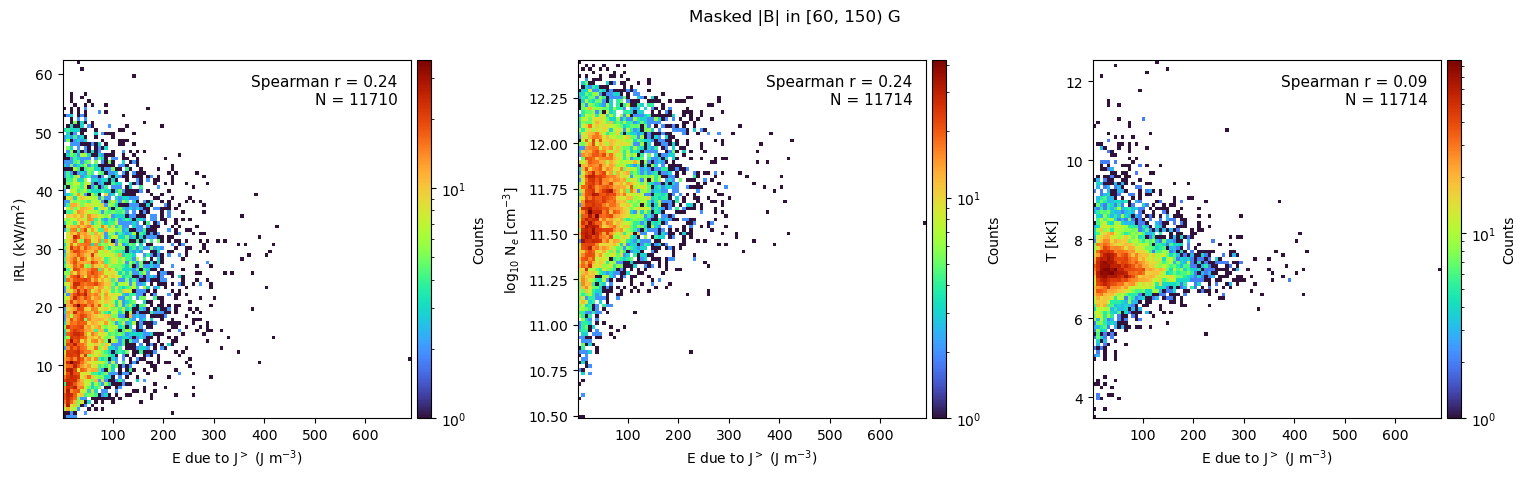

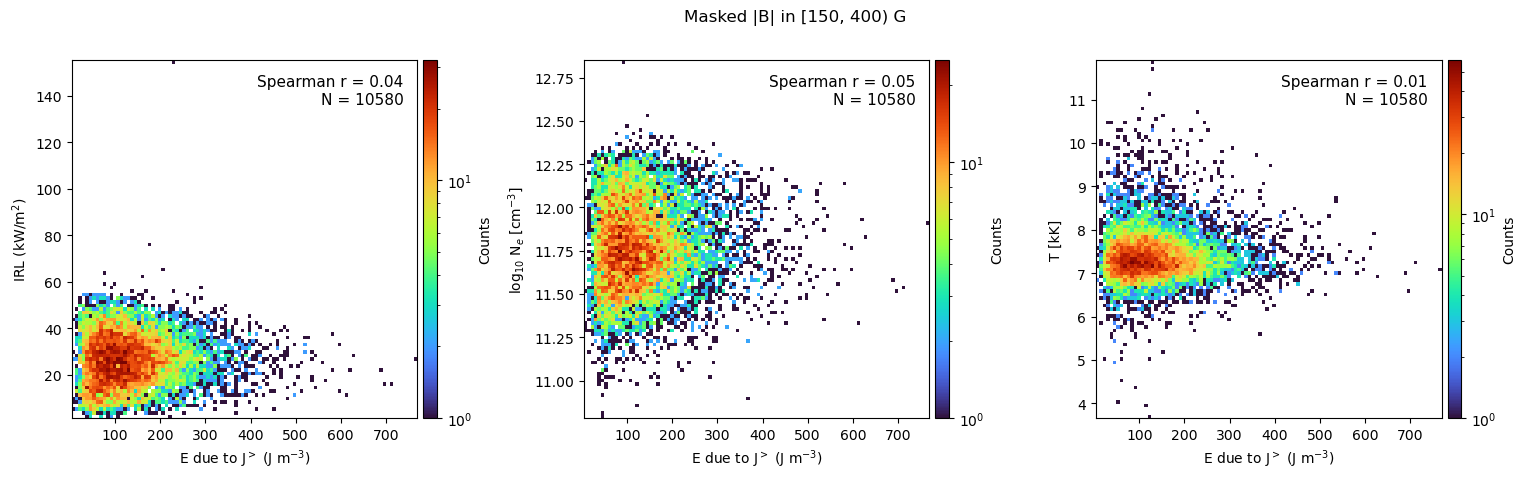

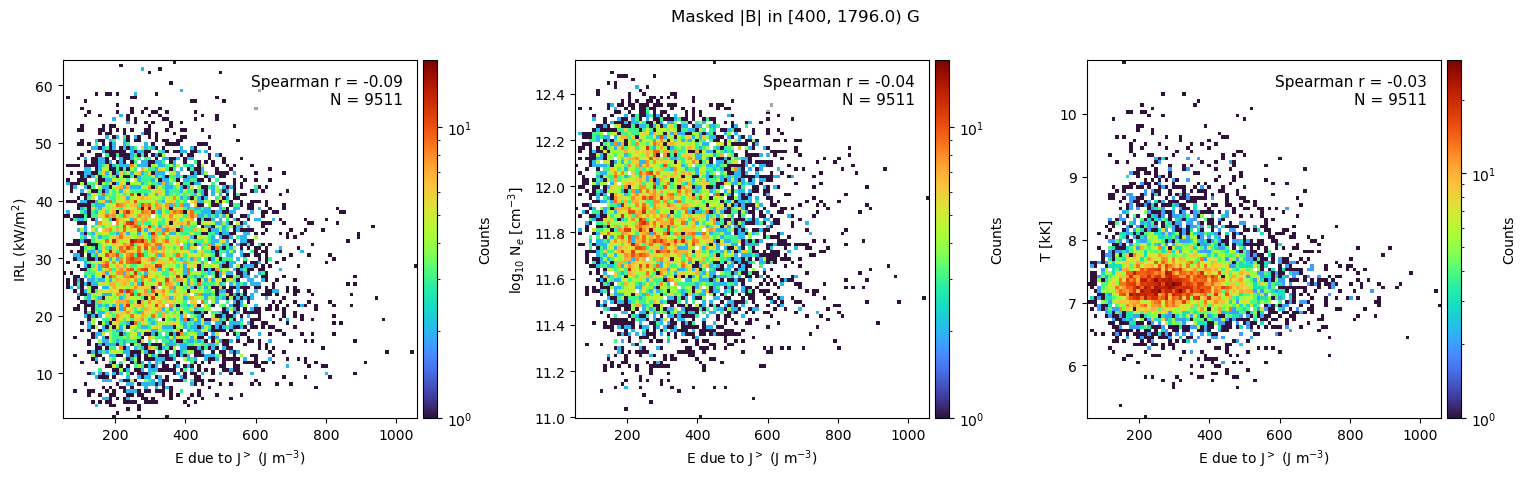

In [253]:
for low, high in b_bins:
    mask_B = ((abs_B >= low) & (abs_B < high)).astype(float)

    y_list = [mask_B * IRL, mask_B * Ne, mask_B * Temp]
    y_title = [r'IRL (kW/m$^{2}$)', r'log$_{10}$ N$_e$ [cm$^{-3}$]', 'T [kK]']
    x = (E_dens_gt * mask_B).flatten()

    fig, ax = plt.subplots(1, len(y_list), figsize=(16, 5), sharex=True)
    ax = np.atleast_1d(ax)

    for yy, (arr, title) in enumerate(zip(y_list, y_title)):
        y = arr.flatten()
        valid = (~np.isnan(x)) & (~np.isnan(y)) & (y > 0)
        x_valid, y_valid = x[valid], y[valid]
        
        if yy == 0:
            y_lim = np.nanpercentile(y_valid, 90)
            ax[yy].set_ylim(top=y_lim)


        if len(x_valid) == 0:
            ax[yy].set_visible(False)
            continue

        y_plot = np.log10(y_valid) if yy == 1 else y_valid
        rho, _ = spearmanr(x_valid, y_plot)

        hist = ax[yy].hist2d(
            x_valid,
            y_plot,
            bins=100,
            cmap='turbo',
            norm=colors.LogNorm(vmin=1),
        )

        ax[yy].text(
            0.96,
            0.96,
            f"Spearman r = {rho:.2f}\nN = {len(x_valid)}",
            transform=ax[yy].transAxes,
            ha='right',
            va='top',
            fontsize=11,
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'),
        )
        ax[yy].set_xlabel(r'E due to J$^{>}$ (J m$^{-3}$)')
        ax[yy].set_ylabel(title)
        # ax[yy].set_title(title.replace('log$_{10}$ ', ''))

        divider = make_axes_locatable(ax[yy])
        cax = divider.append_axes("right", size="4%", pad=0.06)
        cbar = fig.colorbar(hist[-1], cax=cax)
        cbar.set_label('Counts')

    fig.suptitle(f'Masked |B| in [{low}, {high if np.isfinite(high) else "∞"}) G', y=0.95)
    fig.tight_layout(rect=[0, 0, 0.96, 0.94])
    plt.savefig(os.path.join(os.environ['results_dir'],'JPDF_2017_03_05_J>_'+format(low)+'.png'),dpi=300,bbox_inches='tight')
    # plt.show()

In [141]:
### Variation of the median values of IRL and J> per |B| bin. In each |B| bin we chose 10 quantiles with qs = np.quantile(x, np.linspace(0, 1, q + 1))
def profile(x, y, q=10, min_n=100):
    qs = np.quantile(x, np.linspace(0, 1, q + 1))
    mids, med, lo, hi = [], [], [], []
    for i in range(q):
        sel = (x >= qs[i]) & (x < qs[i + 1])
        if sel.sum() < min_n:
            continue
        mids.append(np.median(x[sel]))
        yy = y[sel]
        med.append(np.median(yy))
        lo.append(np.percentile(yy, 25))
        hi.append(np.percentile(yy, 75))
    return np.array(mids), np.array(med), np.array(lo), np.array(hi)


plt.figure(figsize=(6,4))
for b, lab in enumerate(labels):
    if b == 0:
        continue
    m_bin = (bin_id == b)
    if m_bin.sum() < 200:  # skip tiny bins
        continue
    mx, my, lo, hi = profile(E_dens_gt[m_bin], IRL[m_bin], q=10)
    if mx.size == 0:
        continue
    plt.plot(mx, my, '-o', label=lab)
    plt.fill_between(mx, lo, hi, alpha=0.2)
plt.xlabel(r'Energy density $J^{>}$')
plt.ylabel('IRL')
plt.legend(title='|B| bin (G)', ncol=2)
plt.tight_layout()


NameError: name 'bin_id' is not defined

<Figure size 600x400 with 0 Axes>

## Computing the wave Poynting flux proxy using Judge et al. 2024

In [ ]:
rho = 1.17*Ne*1e6*1.67*1e-27 #kg^m3
Bzgt_obs_SI = Bzgt_obs*1e-4 # T
Turb_SI = Turb*1e3 # m/s

S_proxy = np.abs(Bzgt_obs_SI)*(Turb_SI**2)*np.sqrt(rho)*(1/np.sqrt(1.257e-6))*1e-3

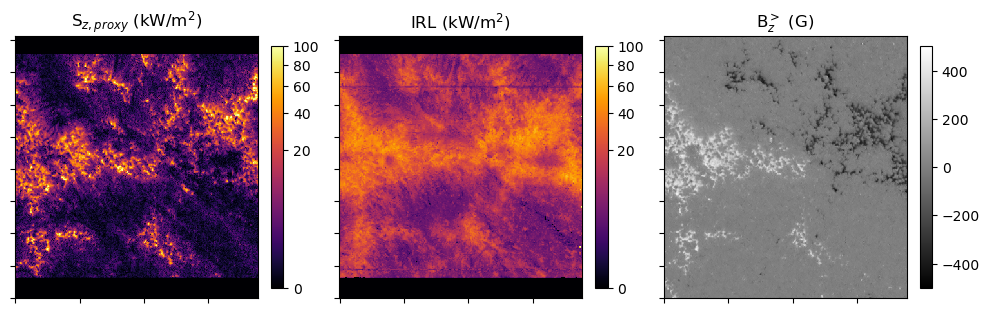

In [290]:
import cmocean
fig, ax= plt.subplots(nrows=1, ncols=3, sharex=True, sharey=True, figsize=(10,5))
ax = ax.ravel()
im=ax[0].imshow((S_proxy[:,:]), origin='lower', cmap='inferno',norm=colors.PowerNorm(0.35,vmin=0,vmax=100), interpolation='none')
plt.colorbar(im, fraction=0.045)
ax[0].set_title('S$_{z, proxy}$ (kW/m$^{2}$)')
ax[0].tick_params(axis='both', labelbottom=False, labelleft=False)
im= ax[1].imshow((IRL[:,:]),origin='lower', cmap='inferno',norm=colors.PowerNorm(0.35,vmin=0,vmax=100), interpolation='none')
plt.colorbar(im, fraction=0.045)
ax[1].tick_params(axis='both', labelbottom=False, labelleft=False)
ax[1].set_title('IRL (kW/m$^{2}$)')

im= ax[2].imshow(Bzgt_obs, origin='lower', cmap='gray', vmin=-500, vmax=500, interpolation='none')
ax[2].set_title(r'B$_{z}^{>}$ (G)')
ax[2].tick_params(axis='both', labelbottom=False, labelleft=False)
plt.colorbar(im, fraction=0.045)
plt.tight_layout()
# plt.savefig(os.path.join(os.environ['results_dir'],'Sz_proxy_IRL_comparison.png'),dpi=300,bbox_inches='tight')

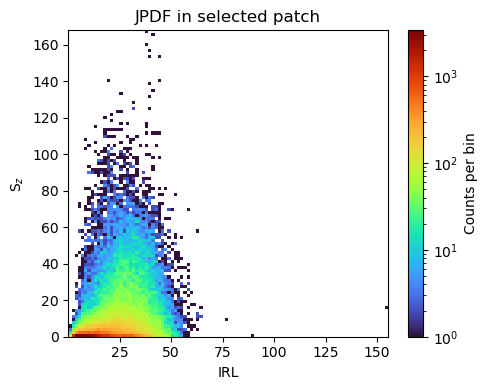

In [159]:
sub_IRL = IRL[150:350,:]
sub_S = S_proxy[150:350,:]
mask = np.isfinite(sub_IRL) & np.isfinite(sub_S) & (sub_IRL > 0)

plt.figure(figsize=(5, 4))
h = plt.hist2d(
    sub_IRL[mask],
    sub_S[mask],
    bins=100,
    cmap='turbo',
    norm=colors.LogNorm()
)
plt.xlabel('IRL')
plt.ylabel(r'S$_{z}$')
plt.title('JPDF in selected patch')
plt.colorbar(h[3], label='Counts per bin')
plt.tight_layout()

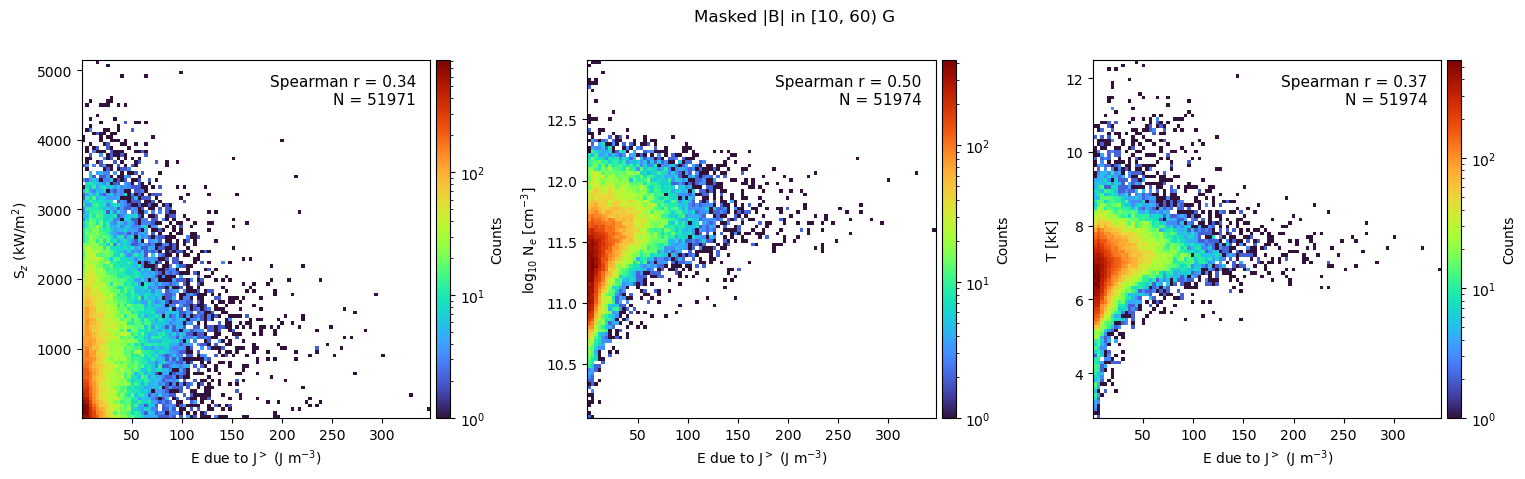

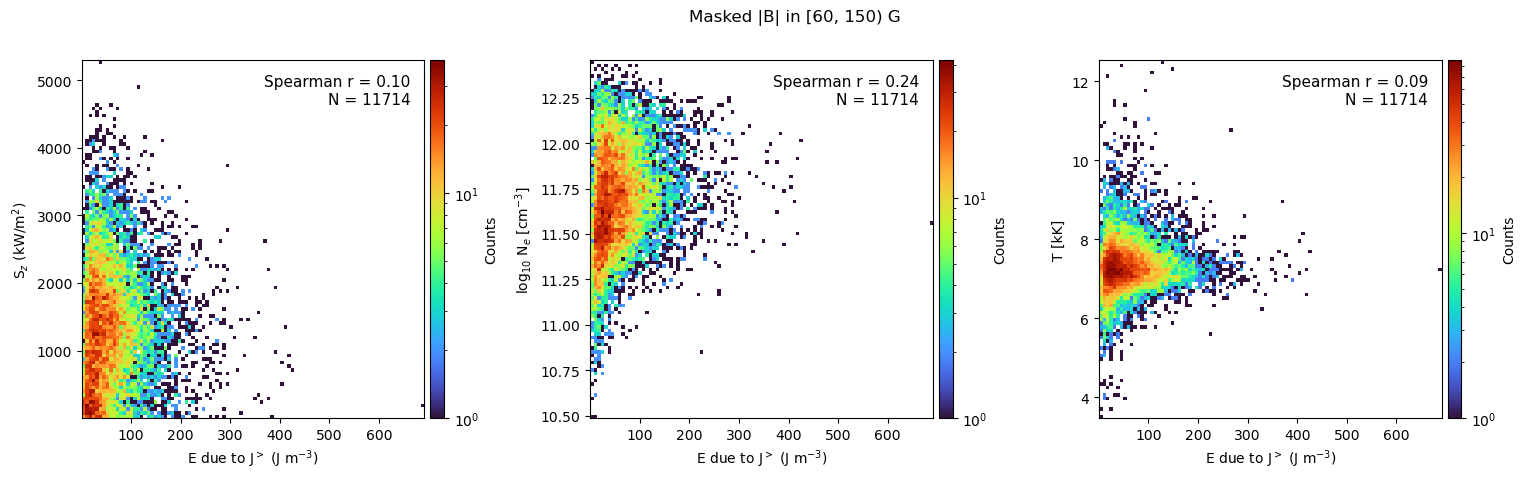

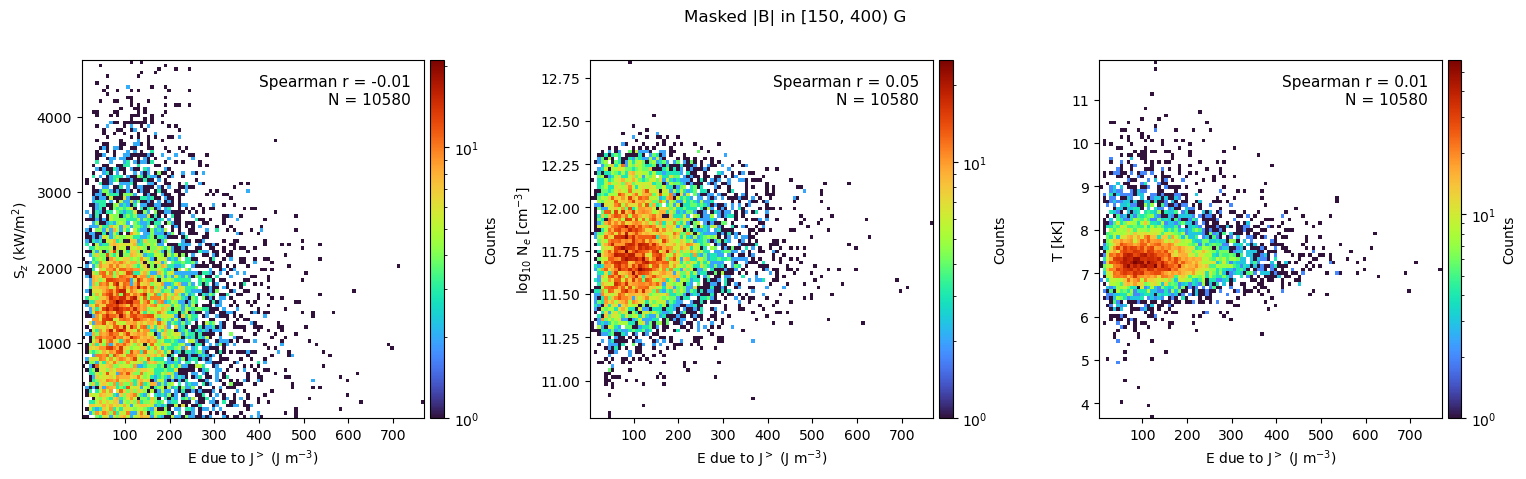

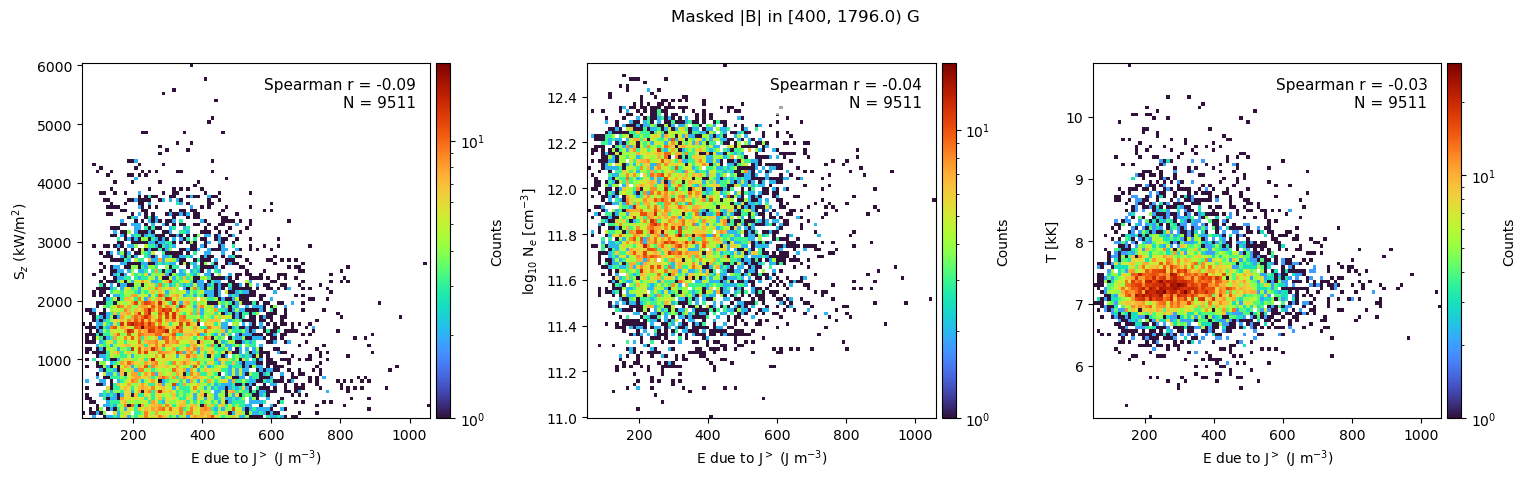

In [277]:
for low, high in b_bins:
    mask_B = ((abs_B >= low) & (abs_B < high)).astype(float)

    y_list = [mask_B * S_proxy/np.abs(Bzgt_obs_SI), mask_B * Ne, mask_B * Temp]
    y_title = [r'S$_{z}$ (kW/m$^{2}$)', r'log$_{10}$ N$_e$ [cm$^{-3}$]', 'T [kK]']
    x = (E_dens_gt * mask_B).flatten()

    fig, ax = plt.subplots(1, len(y_list), figsize=(16, 5), sharex=True)
    ax = np.atleast_1d(ax)

    for yy, (arr, title) in enumerate(zip(y_list, y_title)):
        y = arr.flatten()
        valid = (~np.isnan(x)) & (~np.isnan(y)) & (y > 0)
        x_valid, y_valid = x[valid], y[valid]
        
        if yy == 0:
            y_lim = np.nanpercentile(y_valid, 90)
            ax[yy].set_ylim(top=y_lim)


        if len(x_valid) == 0:
            ax[yy].set_visible(False)
            continue

        y_plot = np.log10(y_valid) if yy == 1 else y_valid
        rho, _ = spearmanr(x_valid, y_plot)

        hist = ax[yy].hist2d(
            x_valid,
            y_plot,
            bins=100,
            cmap='turbo',
            norm=colors.LogNorm(vmin=1),
        )

        ax[yy].text(
            0.96,
            0.96,
            f"Spearman r = {rho:.2f}\nN = {len(x_valid)}",
            transform=ax[yy].transAxes,
            ha='right',
            va='top',
            fontsize=11,
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'),
        )
        ax[yy].set_xlabel(r'E due to J$^{>}$ (J m$^{-3}$)')
        ax[yy].set_ylabel(title)
        # ax[yy].set_title(title.replace('log$_{10}$ ', ''))

        divider = make_axes_locatable(ax[yy])
        cax = divider.append_axes("right", size="4%", pad=0.06)
        cbar = fig.colorbar(hist[-1], cax=cax)
        cbar.set_label('Counts')

    fig.suptitle(f'Masked |B| in [{low}, {high if np.isfinite(high) else "∞"}) G', y=0.95)
    fig.tight_layout(rect=[0, 0, 0.96, 0.94])
    # plt.savefig(os.path.join(os.environ['results_dir'],'JPDF_2017_03_05_Poynting_'+format(low)+'.png'),dpi=300,bbox_inches='tight')
    # plt.savefig(os.path.join(os.environ['results_dir'],'JPDF_J>_'+format(low)+'.png'),dpi=300,bbox_inches='tight')
    # plt.show()

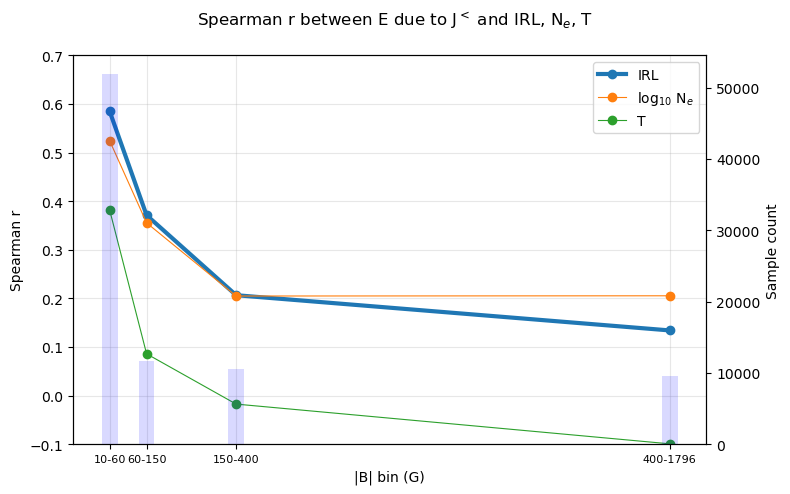

In [15]:
b_bins = [(10, 60), (60, 150), (150, 400), (400, np.round(np.max(np.abs(Bz))))]
bin_labels = [f"{low}-{int(high) if np.isfinite(high) else '∞'}" for low, high in b_bins]
bin_centers = np.array([np.mean([low, high if np.isfinite(high) else low * 1.75]) for low, high in b_bins])

rho_S, rho_irl, rho_ne, rho_temp = [], [], [], []
counts = []
from scipy.stats import kendalltau
for low, high in b_bins:
    mask_B = ((np.abs(Bz) >= low) & (np.abs(Bz) < high)).astype(float)

    x = (E_dens_lt * mask_B).flatten()
    y_IRL = (mask_B * IRL).flatten()
    y_Ne = (mask_B * Ne).flatten()
    y_T = (mask_B * Temp).flatten()
    # y_S = (mask_B * S_proxy/np.abs(Bzgt_obs_SI)).flatten()

    valid_IRL = (~np.isnan(x)) & (~np.isnan(y_IRL)) & (y_IRL > 0)
    valid_Ne = (~np.isnan(x)) & (~np.isnan(y_Ne)) & (y_Ne > 0)
    valid_T = (~np.isnan(x)) & (~np.isnan(y_T)) & (y_T > 0)
    # valid_S = (~np.isnan(x)) & (~np.isnan(y_S)) & (y_S > 0)

    counts.append(valid_IRL.sum())

    rho_irl.append(spearmanr(x[valid_IRL], y_IRL[valid_IRL]).correlation)
    rho_ne.append(spearmanr(x[valid_Ne], np.log10(y_Ne[valid_Ne])).correlation)
    rho_temp.append(spearmanr(x[valid_T], y_T[valid_T]).correlation)
    # rho_S.append(spearmanr(x[valid_S], y_S[valid_S]).correlation)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(bin_centers, rho_irl, '-o', label='IRL', color='tab:blue',lw=3)
# ax.plot(bin_centers, rho_S, '--o', label=r'S$_{z, proxy}$/|B$_{z}^{>}$|', color='tab:blue')
ax.plot(bin_centers, rho_ne, '-o', label=r'log$_{10}$ N$_e$', color='tab:orange',lw=0.8)
ax.plot(bin_centers, rho_temp, '-o', label='T', color='tab:green',lw=0.8)

ax.set_xticks(bin_centers)
ax.set_xticklabels(bin_labels,fontsize=8)
ax.set_ylim(-0.1, 0.7)
ax.set_xlabel(r'|B| bin (G)')
ax.set_ylabel('Spearman r')
ax.grid(alpha=0.3)
ax.legend()

ax2 = ax.twinx()
ax2.bar(bin_centers, counts, width=30, alpha=0.15, color='blue')
ax2.set_ylabel('Sample count')
fig.suptitle('Spearman r between E due to J$^{<}$ and IRL, N$_e$, T')
fig.tight_layout()

# plt.show()
# plt.savefig(os.path.join(os.environ['results_dir'],'Spearman_r_vs_B_bins.png'),dpi=300,bbox_inches='tight')


## Sliding window to compute $\mathcal{E}$(B) (heating-effiicacy curve)

In [16]:
def boot_ci_rho(x, y, nboot=300):
    r = []
    n = x.size
    for _ in range(nboot):
        idx = np.random.randint(0, n, n)
        r.append(spearmanr(x[idx], y[idx]).statistic)
    r = np.sort(r)
    return (np.median(r), r[int(0.16*nboot)], r[int(0.84*nboot)])

def sliding_spearman_with_ci(Babs, X, Y, win=60, step=10, min_pts=400, nboot=300):
    from collections import namedtuple
    Out = namedtuple('Out', 'mids rhos lo hi Ns')
    B = np.asarray(Babs); X = np.asarray(X); Y = np.asarray(Y)
    mids, rhos, lo, hi, Ns = [], [], [], [], []
    bmin, bmax = np.percentile(B[np.isfinite(B)], [1, 99])
    b = bmin
    while b + win <= bmax:
        sel = np.isfinite(B) & np.isfinite(X) & np.isfinite(Y) & (B >= b) & (B < b+win)
        if sel.sum() >= min_pts:
            med, lo1, hi1 = boot_ci_rho(X[sel], Y[sel], nboot=nboot)
            mids.append(b + win/2); rhos.append(med); lo.append(lo1); hi.append(hi1); Ns.append(sel.sum())
        b += step
    return Out(np.array(mids), np.array(rhos), np.array(lo), np.array(hi), np.array(Ns))


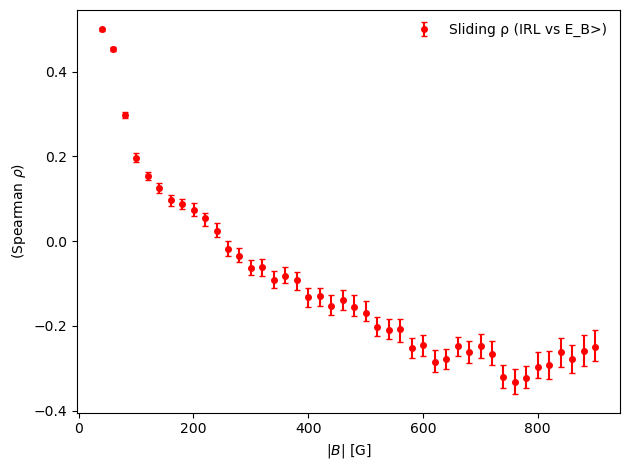

In [17]:
mask = IRL > 5.
out = sliding_spearman_with_ci(abs_B[mask], IRL[mask], E_dens_gt[mask], win=80, step=20, min_pts=400, nboot=300)
Bs = np.linspace(out.mids.min()*0.8, out.mids.max()*1.2, 400)
plt.errorbar(out.mids, out.rhos, yerr=[out.rhos-out.lo, out.hi-out.rhos],
             fmt='o', ms=4, capsize=2, label='Sliding ρ (IRL vs E_B>)',color='red')
# plt.plot(Bs, fit, lw=2, label=f'Fit: A={A:.2f}, Bc={Bc:.0f} G, p={p:.2f}, C={C:.2f}\nB_peak={Bpeak:.0f} G')
# plt.axvline(Bpeak, ls='--', alpha=0.5)
plt.xlabel(r'$|B|$ [G]'); plt.ylabel(r'(Spearman $\rho$)')
plt.legend(frameon=False); plt.tight_layout();


## Statistics based on Brian's comments
$\bullet$ $\Delta$ E as x-axis

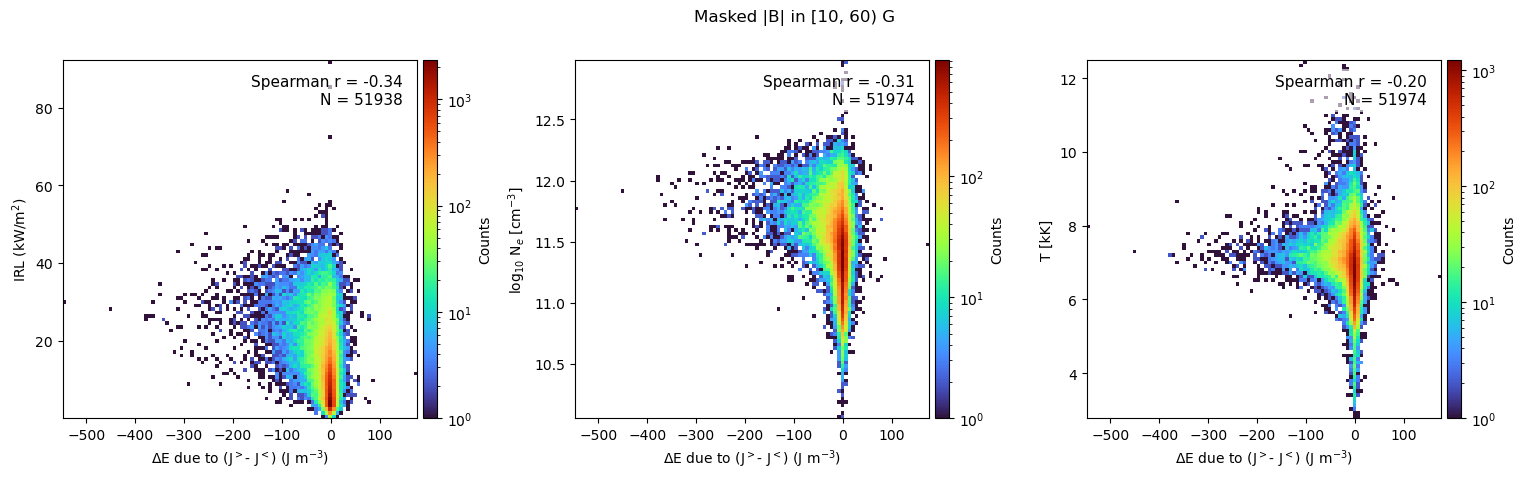

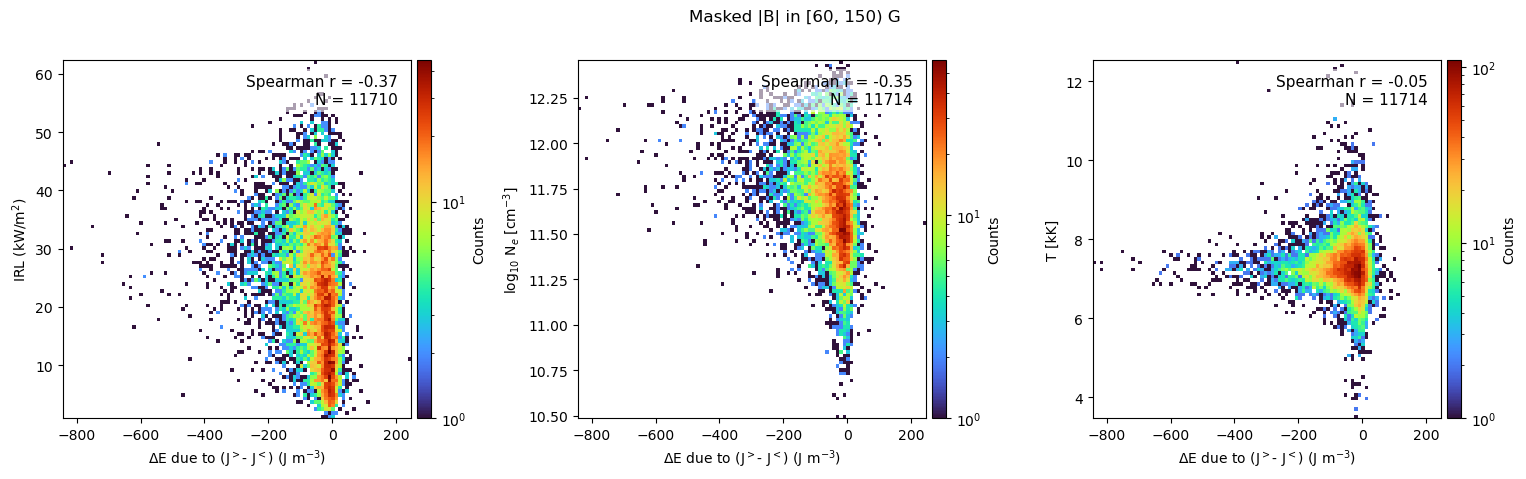

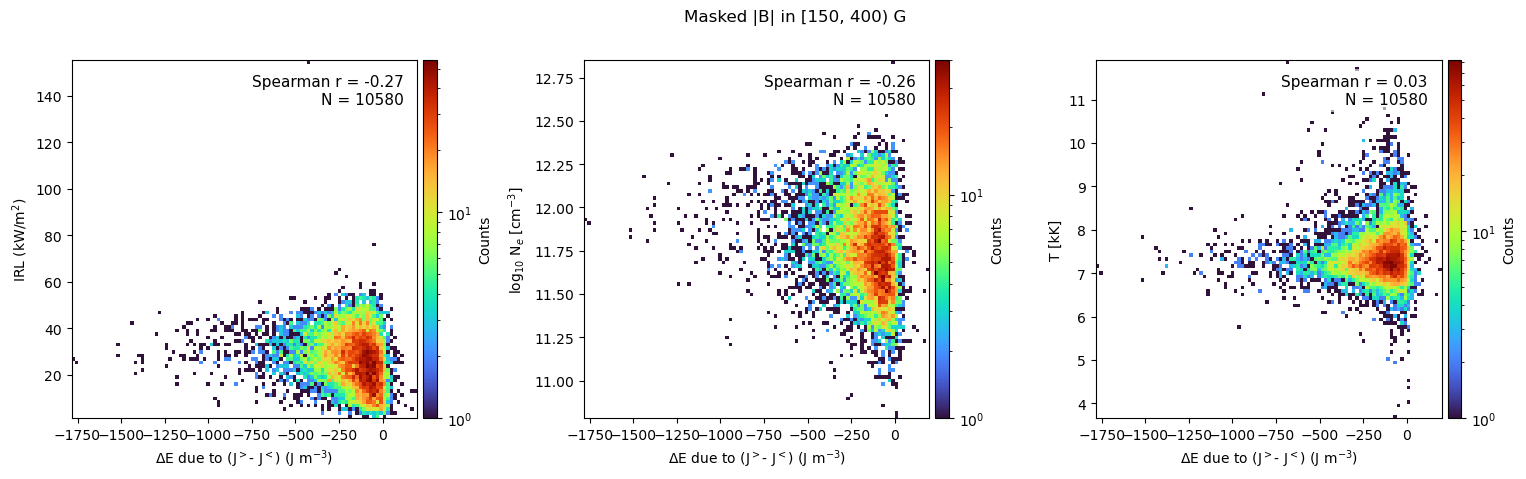

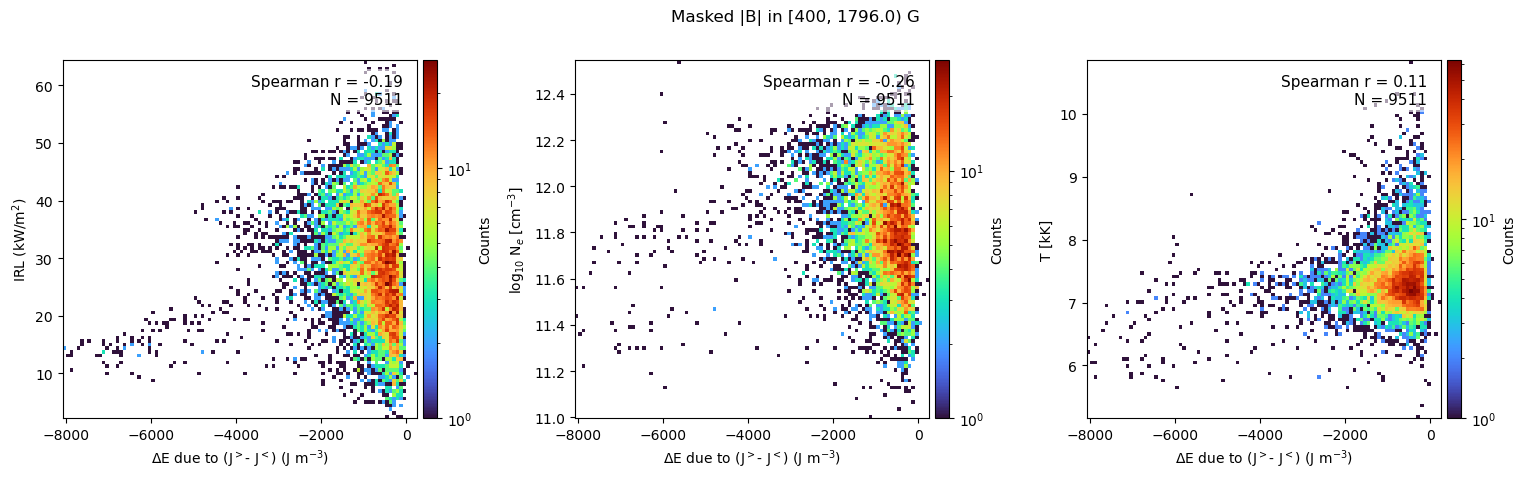

In [13]:
for low, high in b_bins:
    mask_B = ((abs_B >= low) & (abs_B < high)).astype(float)

    y_list = [mask_B * IRL, mask_B * Ne, mask_B * Temp]
    y_title = [r'IRL (kW/m$^{2}$)', r'log$_{10}$ N$_e$ [cm$^{-3}$]', 'T [kK]']
    x = ((E_dens_gt-E_dens_lt) * mask_B).flatten()

    fig, ax = plt.subplots(1, len(y_list), figsize=(16, 5), sharex=True)
    ax = np.atleast_1d(ax)

    for yy, (arr, title) in enumerate(zip(y_list, y_title)):
        y = arr.flatten()
        valid = (~np.isnan(x)) & (~np.isnan(y)) & (y > 0)
        x_valid, y_valid = x[valid], y[valid]
        
        if yy == 0:
            y_lim = np.nanpercentile(y_valid, 90)
            ax[yy].set_ylim(top=y_lim)


        if len(x_valid) == 0:
            ax[yy].set_visible(False)
            continue

        y_plot = np.log10(y_valid) if yy == 1 else y_valid
        rho, _ = spearmanr(x_valid, y_plot)

        hist = ax[yy].hist2d(
            x_valid,
            y_plot,
            bins=100,
            cmap='turbo',
            norm=colors.LogNorm(vmin=1),
        )

        ax[yy].text(
            0.96,
            0.96,
            f"Spearman r = {rho:.2f}\nN = {len(x_valid)}",
            transform=ax[yy].transAxes,
            ha='right',
            va='top',
            fontsize=11,
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'),
        )
        ax[yy].set_xlabel(r'$\Delta$E due to (J$^{>}$- J$^{<}$) (J m$^{-3}$)')
        ax[yy].set_ylabel(title)
        # ax[yy].set_title(title.replace('log$_{10}$ ', ''))

        divider = make_axes_locatable(ax[yy])
        cax = divider.append_axes("right", size="4%", pad=0.06)
        cbar = fig.colorbar(hist[-1], cax=cax)
        cbar.set_label('Counts')

    fig.suptitle(f'Masked |B| in [{low}, {high if np.isfinite(high) else "∞"}) G', y=0.95)
    fig.tight_layout(rect=[0, 0, 0.96, 0.94])
    # plt.savefig(os.path.join(os.environ['results_dir'],'JPDF_2017_03_05_J>_'+format(low)+'.png'),dpi=300,bbox_inches='tight')
    # plt.show()

$\bullet$ Let's check the baseline: |B_z|

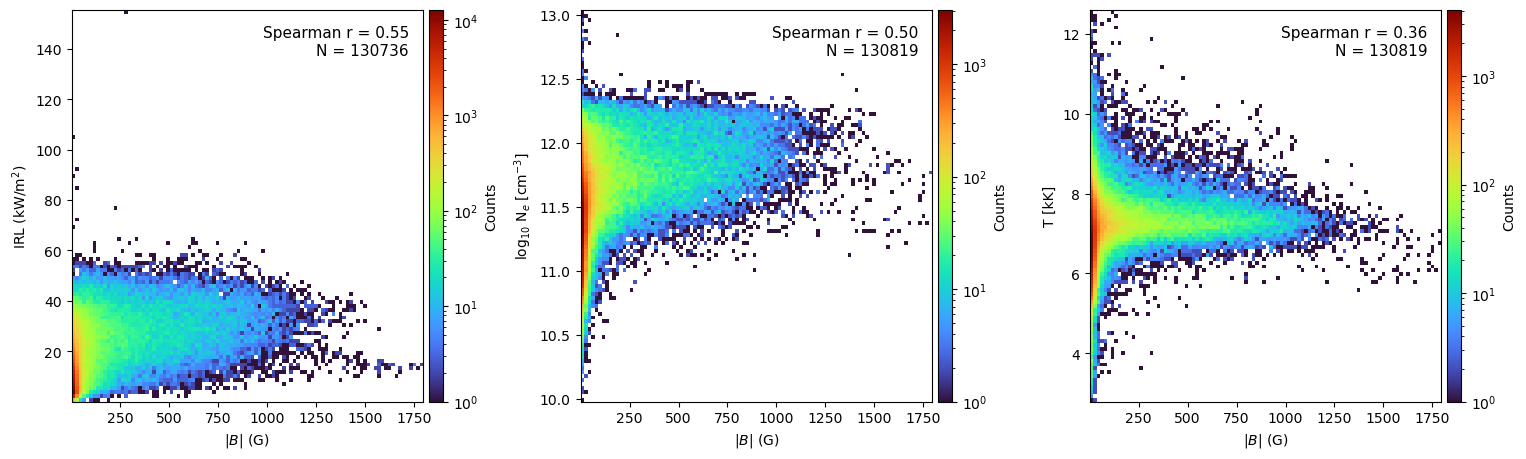

In [100]:
y_list = [IRL,  Ne, Temp]
y_title = [r'IRL (kW/m$^{2}$)', r'log$_{10}$ N$_e$ [cm$^{-3}$]', 'T [kK]']
# x = ((E_dens_gt-E_dens_lt) * mask_B).flatten()
x = (abs_B).flatten()

fig, ax = plt.subplots(1, len(y_list), figsize=(16, 5), sharex=True)
ax = np.atleast_1d(ax)

for yy, (arr, title) in enumerate(zip(y_list, y_title)):
    y = arr.flatten()
    valid = (~np.isnan(x)) & (~np.isnan(y)) & (y > 0)
    x_valid, y_valid = x[valid], y[valid]
    
    if yy == 0:
        y_lim = np.nanpercentile(y_valid, 90)
        ax[yy].set_ylim(top=y_lim)


    if len(x_valid) == 0:
        ax[yy].set_visible(False)
        continue

    y_plot = np.log10(y_valid) if yy == 1 else y_valid
    rho, _ = spearmanr(x_valid, y_plot)

    hist = ax[yy].hist2d(
        x_valid,
        y_plot,
        bins=100,
        cmap='turbo',
        norm=colors.LogNorm(vmin=1),
    )

    ax[yy].text(
        0.96,
        0.96,
        f"Spearman r = {rho:.2f}\nN = {len(x_valid)}",
        transform=ax[yy].transAxes,
        ha='right',
        va='top',
        fontsize=11,
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'),
    )
    ax[yy].set_xlabel(r'$|B|$ (G)')
    ax[yy].set_ylabel(title)
    # ax[yy].set_xlim([10,250])
    # ax[yy].set_xlim(np.nanpercentile(abs_B, [0.5, 99.5]))
    # ax[yy].set_xscale('log')
    # ax[yy].set_title(title.replace('log$_{10}$ ', ''))

    divider = make_axes_locatable(ax[yy])
    cax = divider.append_axes("right", size="4%", pad=0.06)
    cbar = fig.colorbar(hist[-1], cax=cax)
    cbar.set_label('Counts')

# fig.suptitle(f'Masked |B| in [{low}, {high if np.isfinite(high) else "∞"}) G', y=0.95)
fig.tight_layout(rect=[0, 0, 0.96, 0.94])
# plt.savefig(os.path.join(os.environ['results_dir'],'JPDF_2017_03_05_baseline'+format(low)+'.png'),dpi=300,bbox_inches='tight')
# plt.show()

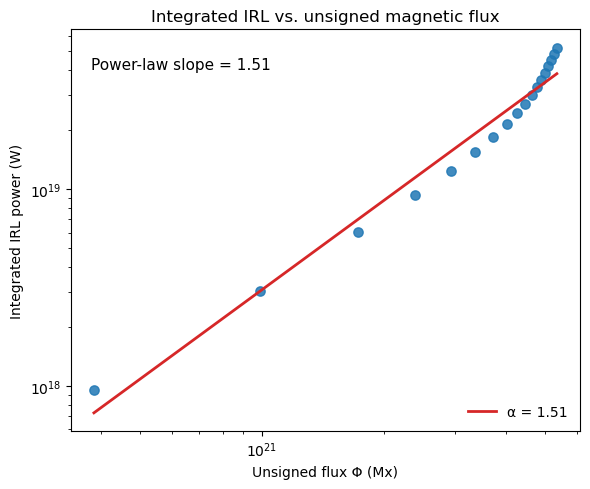

In [44]:
# Integrated IRL vs unsigned magnetic flux using actual SOT sampling
x_sampling_sot = 0.29714  # arcsec per pixel (x)
y_sampling_sot = 0.317    # arcsec per pixel (y)
km_per_arcsec = 725.0     # disk-center conversion

pixel_size_x_m = x_sampling_sot * km_per_arcsec * 1e3
pixel_size_y_m = y_sampling_sot * km_per_arcsec * 1e3
pixel_area_m2 = pixel_size_x_m * pixel_size_y_m
pixel_area_cm2 = (pixel_size_x_m * 100.0) * (pixel_size_y_m * 100.0)

abs_B = np.abs(Bz)
valid = np.isfinite(abs_B) & np.isfinite(IRL) & (IRL > 0)

b_thresholds = np.geomspace(30, np.nanpercentile(abs_B[valid], 99.5), 18)

phi_total, irl_power = [], []
for b_min in b_thresholds:
    sel = valid & (abs_B >= b_min)
    if sel.sum() < 50:
        continue
    phi_total.append(np.nansum(abs_B[sel]) * pixel_area_cm2)      # Mx
    irl_power.append(np.nansum(IRL[sel]) * 1e3 * pixel_area_m2)   # W

phi_total = np.asarray(phi_total)
irl_power = np.asarray(irl_power)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(phi_total, irl_power, s=45, color='tab:blue', alpha=0.85)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'Unsigned flux Φ (Mx)')
ax.set_ylabel(r'Integrated IRL power (W)')

mask = (phi_total > 0) & (irl_power > 0)
if mask.sum() >= 3:
    logx = np.log10(phi_total[mask])
    logy = np.log10(irl_power[mask])
    slope, intercept = np.polyfit(logx, logy, 1)
    xfit = np.linspace(logx.min(), logx.max(), 200)
    ax.plot(10**xfit, 10**(slope * xfit + intercept),
            color='tab:red', lw=2, label=f'α = {slope:.2f}')
    ax.text(0.04, 0.93, f'Power-law slope = {slope:.2f}',
            transform=ax.transAxes, ha='left', va='top',
            fontsize=11, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    ax.legend(loc='lower right', frameon=False)

ax.set_title('Integrated IRL vs. unsigned magnetic flux')
fig.tight_layout()
plt.show()


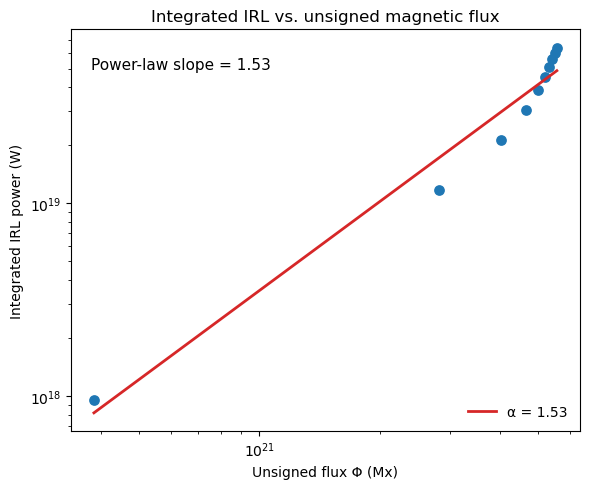

In [99]:
# Integrated IRL vs unsigned magnetic flux using actual SOT sampling
x_sampling_sot = 0.29714  # arcsec per pixel (x)
y_sampling_sot = 0.317    # arcsec per pixel (y)
km_per_arcsec = 725.0     # disk-center conversion

pixel_size_x_m = x_sampling_sot * km_per_arcsec * 1e3
pixel_size_y_m = y_sampling_sot * km_per_arcsec * 1e3
pixel_area_m2 = pixel_size_x_m * pixel_size_y_m
pixel_area_cm2 = (pixel_size_x_m * 100.0) * (pixel_size_y_m * 100.0)

abs_B = np.abs(Bz)
valid = np.isfinite(abs_B) & np.isfinite(IRL) & (IRL > 0)
percentiles = np.linspace(50, 99.5, 10)  # adjust count/range as needed
b_thresholds = np.nanpercentile(abs_B[valid], percentiles)

phi_total, irl_power = [], []
for b_min in b_thresholds:
    sel = valid & (abs_B >= b_min)
    if sel.sum() < 50:      # skip tiny samples
        continue
    phi_total.append(np.nansum(abs_B[sel]) * pixel_area_cm2)
    irl_power.append(np.nansum(IRL[sel]) * 1e3 * pixel_area_m2)

phi_total = np.asarray(phi_total)
irl_power = np.asarray(irl_power)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(phi_total, irl_power, s=45, color='tab:blue')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'Unsigned flux Φ (Mx)')
ax.set_ylabel(r'Integrated IRL power (W)')

mask = (phi_total > 0) & (irl_power > 0)
if mask.sum() >= 3:
    logx = np.log10(phi_total[mask])
    logy = np.log10(irl_power[mask])
    slope, intercept = np.polyfit(logx, logy, 1)
    xfit = np.linspace(logx.min(), logx.max(), 200)
    ax.plot(10**xfit, 10**(slope * xfit + intercept),
            color='tab:red', lw=2, label=f'α = {slope:.2f}')
    ax.text(0.04, 0.93, f'Power-law slope = {slope:.2f}',
            transform=ax.transAxes, ha='left', va='top',
            fontsize=11,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    ax.legend(loc='lower right', frameon=False)

ax.set_title('Integrated IRL vs. unsigned magnetic flux')
fig.tight_layout()
plt.show()


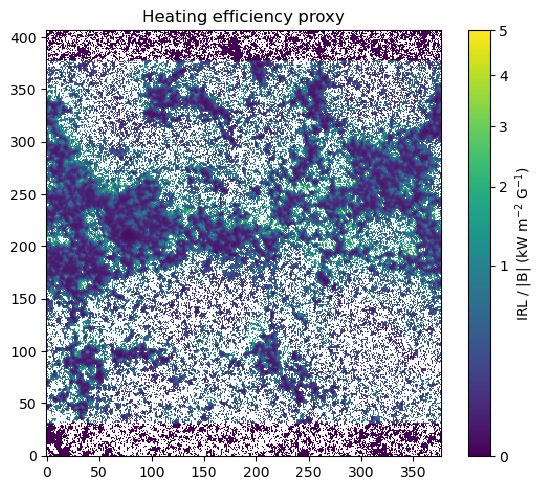

In [22]:
B_threshold = 10  # Gauss
heating_efficiency = IRL / np.maximum(abs_B, B_threshold)
mask = abs_B > 10
heating_efficiency = np.full_like(IRL, np.nan)
heating_efficiency[mask] = IRL[mask] / abs_B[mask]
plt.figure(figsize=(6,5))
im = plt.imshow(heating_efficiency, origin='lower', cmap='viridis', norm=colors.PowerNorm(0.5, vmin=0, vmax=5), interpolation='none')
plt.colorbar(im, label=r'IRL / |B| (kW m$^{-2}$ G$^{-1}$)')
plt.title('Heating efficiency proxy')
plt.tight_layout()

Text(0.5, 1.0, 'Heating Efficiency with Magnetic Field Contours')

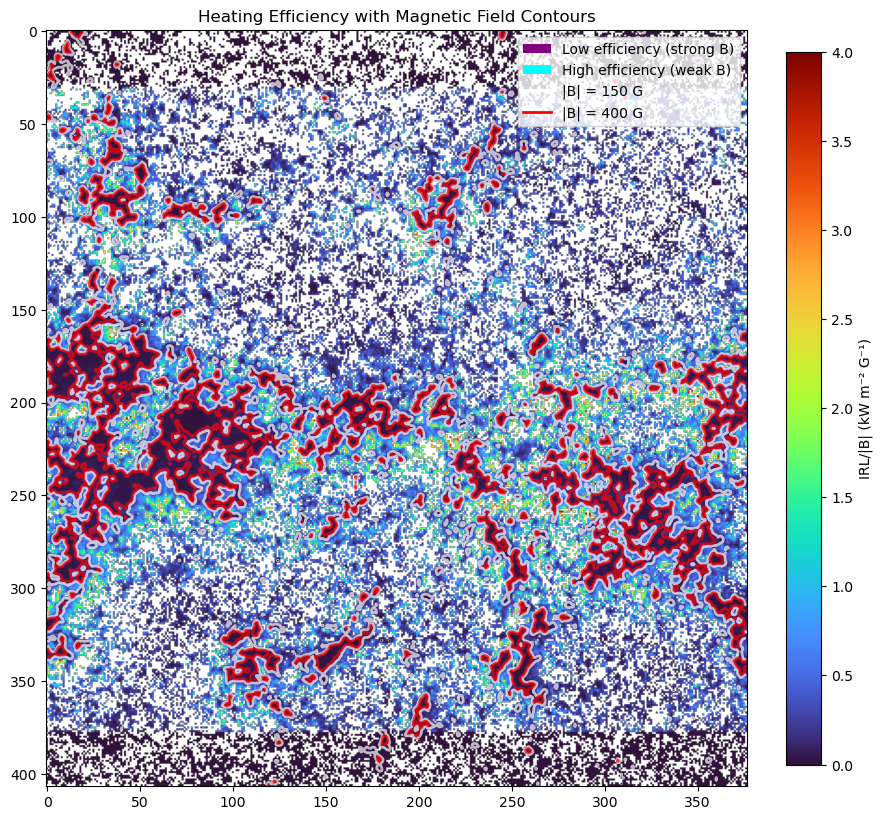

In [23]:
fig, ax = plt.subplots(figsize=(10, 10))

# Show efficiency map
im = ax.imshow(heating_efficiency, cmap='turbo', vmin=0, vmax=4)

# Overlay magnetic field contours
ax.contour(abs_B, levels=[150, 400], colors=['white', 'red'], 
           linewidths=2, alpha=0.7)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='purple', label='Low efficiency (strong B)'),
    Patch(facecolor='cyan', label='High efficiency (weak B)'),
    plt.Line2D([0], [0], color='white', linewidth=2, label='|B| = 150 G'),
    plt.Line2D([0], [0], color='red', linewidth=2, label='|B| = 400 G')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.colorbar(im, ax=ax, label='IRL/|B| (kW m⁻² G⁻¹)',fraction=0.046)
ax.set_title('Heating Efficiency with Magnetic Field Contours')

In [24]:
# Define field regimes
weak_mask = (abs_B >= 10) & (abs_B < 150)
moderate_mask = (abs_B >= 150) & (abs_B < 400)
strong_mask = abs_B >= 400

# Area fractions
total_pixels = (abs_B >= 10).sum()
weak_frac = weak_mask.sum() / total_pixels
moderate_frac = moderate_mask.sum() / total_pixels
strong_frac = strong_mask.sum() / total_pixels

# Median efficiencies
weak_eff = np.nanmedian(heating_efficiency[weak_mask])
moderate_eff = np.nanmedian(heating_efficiency[moderate_mask])
strong_eff = np.nanmedian(heating_efficiency[strong_mask])

# Total heating contribution
weak_heating = np.nansum(IRL[weak_mask])
moderate_heating = np.nansum(IRL[moderate_mask])
strong_heating = np.nansum(IRL[strong_mask])
total_heating = weak_heating + moderate_heating + strong_heating

print("=== Heating Budget Analysis ===")
print(f"\nArea fractions:")
print(f"  Weak (<150 G):     {weak_frac*100:.1f}%")
print(f"  Moderate (150-400): {moderate_frac*100:.1f}%")
print(f"  Strong (>400 G):   {strong_frac*100:.1f}%")

print(f"\nMedian efficiency (kW m⁻² G⁻¹):")
print(f"  Weak:     {weak_eff:.2f}")
print(f"  Moderate: {moderate_eff:.2f}")
print(f"  Strong:   {strong_eff:.2f}")

print(f"\nHeating contribution:")
print(f"  Weak:     {weak_heating/total_heating*100:.1f}%")
print(f"  Moderate: {moderate_heating/total_heating*100:.1f}%")
print(f"  Strong:   {strong_heating/total_heating*100:.1f}%")

print(f"\nFlux contribution:")
total_flux = np.nansum(abs_B[abs_B >= 10])
weak_flux = np.nansum(abs_B[weak_mask]) / total_flux * 100
moderate_flux = np.nansum(abs_B[moderate_mask]) / total_flux * 100
strong_flux = np.nansum(abs_B[strong_mask]) / total_flux * 100
print(f"  Weak:     {weak_flux:.1f}%")
print(f"  Moderate: {moderate_flux:.1f}%")
print(f"  Strong:   {strong_flux:.1f}%")

=== Heating Budget Analysis ===

Area fractions:
  Weak (<150 G):     78.4%
  Moderate (150-400): 11.5%
  Strong (>400 G):   10.1%

Median efficiency (kW m⁻² G⁻¹):
  Weak:     0.34
  Moderate: 0.10
  Strong:   0.04

Heating contribution:
  Weak:     62.1%
  Moderate: 18.8%
  Strong:   19.1%

Flux contribution:
  Weak:     22.3%
  Moderate: 23.2%
  Strong:   54.5%


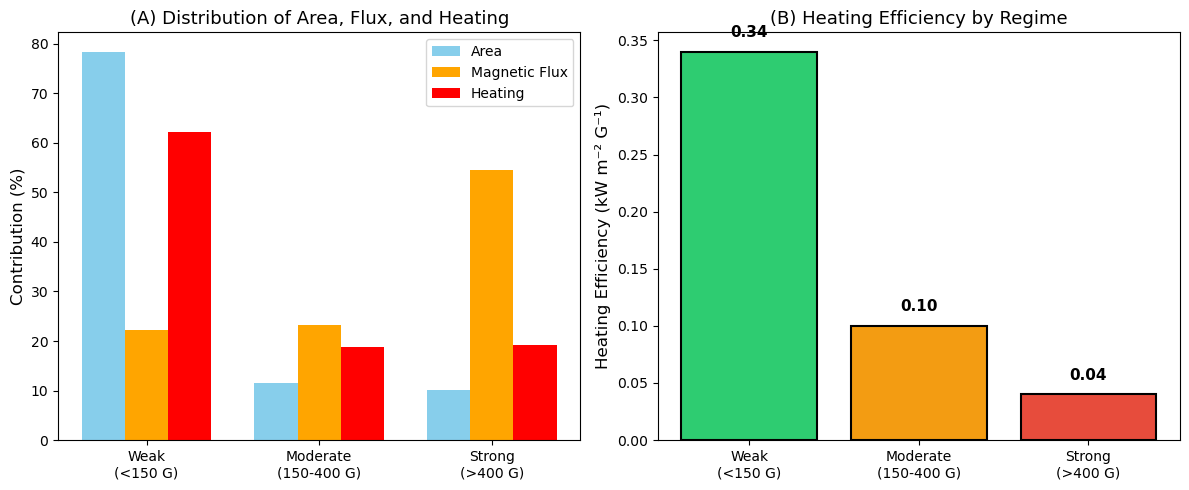

In [25]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Data
regimes = ['Weak\n(<150 G)', 'Moderate\n(150-400 G)', 'Strong\n(>400 G)']
area_frac = [78.4, 11.5, 10.1]
flux_frac = [22.3, 23.2, 54.5]
heating_frac = [62.1, 18.8, 19.1]
efficiency = [0.34, 0.10, 0.04]

x = np.arange(len(regimes))
width = 0.25

# Panel A: Contributions
ax1.bar(x - width, area_frac, width, label='Area', color='skyblue')
ax1.bar(x, flux_frac, width, label='Magnetic Flux', color='orange')
ax1.bar(x + width, heating_frac, width, label='Heating', color='red')

ax1.set_ylabel('Contribution (%)', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(regimes)
ax1.legend()
ax1.set_title('(A) Distribution of Area, Flux, and Heating', fontsize=13)
# ax1.grid(axis='y', alpha=0.3)

# Panel B: Efficiency
colors = ['#2ecc71', '#f39c12', '#e74c3c']  # Green, orange, red
bars = ax2.bar(regimes, efficiency, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Heating Efficiency (kW m⁻² G⁻¹)', fontsize=12)
ax2.set_title('(B) Heating Efficiency by Regime', fontsize=13)
# ax2.grid(axis='y', alpha=0.3)

# Add efficiency values on bars
for bar, eff in zip(bars, efficiency):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{eff:.2f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add annotation showing ratio
# ax2.annotate('', xy=(2, 0.04), xytext=(0, 0.34),
#             arrowprops=dict(arrowstyle='<->', color='black', lw=2))
# ax2.text(1, 0.20, '8.5×', fontsize=14, fontweight='bold',
#          bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.savefig('heating_budget_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


### Make the IRL/|Bz| plots with |Bz| similar to the simulated sigma Q/Bz plots

In [58]:
heating_efficiency.shape, IRL.shape

((407, 377), (407, 377))

In [69]:
b_edges   = np.array([10,100,150,200,400,800,1200,1600,], float)
b_centers = 0.5*(b_edges[1:]+b_edges[:-1])
med_H = np.full(b_centers.size, np.nan)
p25_H = np.full_like(med_H, np.nan) 
p75_H = np.full_like(med_H, np.nan)
mean_IRL = np.full_like(med_H, np.nan)
p25_IRL = np.full_like(med_H, np.nan)
p75_IRL = np.full_like(med_H, np.nan)
for i in range(b_centers.size):
    b_low = b_edges[i]
    b_high= b_edges[i+1]
    mask_B = (abs_B >= b_low) & (abs_B < b_high)
    if mask_B.sum() < 100:
        continue
    med_H[i] = np.nanmedian(heating_efficiency[mask_B])
    p25_H[i] = np.nanpercentile(heating_efficiency[mask_B], 25)
    p75_H[i] = np.nanpercentile(heating_efficiency[mask_B], 75)
    mean_IRL[i] = np.nanmean(IRL[mask_B])
    p25_IRL[i] = np.nanpercentile(IRL[mask_B], 25)
    p75_IRL[i] = np.nanpercentile(IRL[mask_B], 75)



Text(0.5, 1.0, 'Observation')

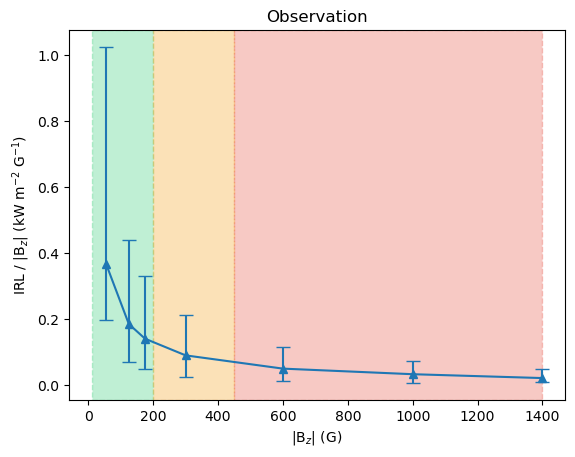

In [96]:
plt.errorbar(b_centers,med_H,yerr =[p25_H,p75_H],fmt='-^', capsize=5)
plt.ylabel(r'IRL / |B$_{z}$| (kW m$^{-2}$ G$^{-1}$)')
plt.xlabel('|B$_{z}$| (G)')
plt.axvspan(10,200, color='#2ecc71', alpha=0.3, ls ='--')
plt.axvspan(200,450, color='#f39c12', alpha=0.3, ls ='--')
plt.axvspan(450,1400, color='#e74c3c',alpha=0.3, ls ='--')
plt.title('Observation')
# plt.yscale('log')
# plt.xscale('log')

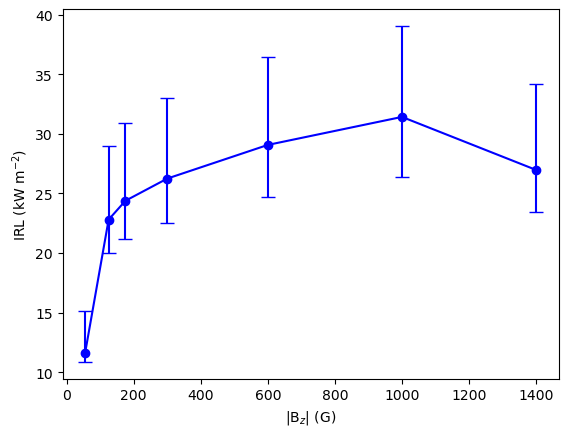

In [124]:
plt.errorbar(b_centers,mean_IRL,yerr =[0.2*p25_IRL,0.2*p75_IRL], fmt='-o', capsize=5, color='blue')
plt.ylabel('IRL (kW m$^{-2}$)')
# plt.xscale('log')
plt.xlabel('|B$_{z}$| (G)')
# plt.yscale('log')
plt.savefig(os.path.join(os.environ['results_dir'],'IRL_vs_Bz.png'),dpi=300,bbox_inches='tight')

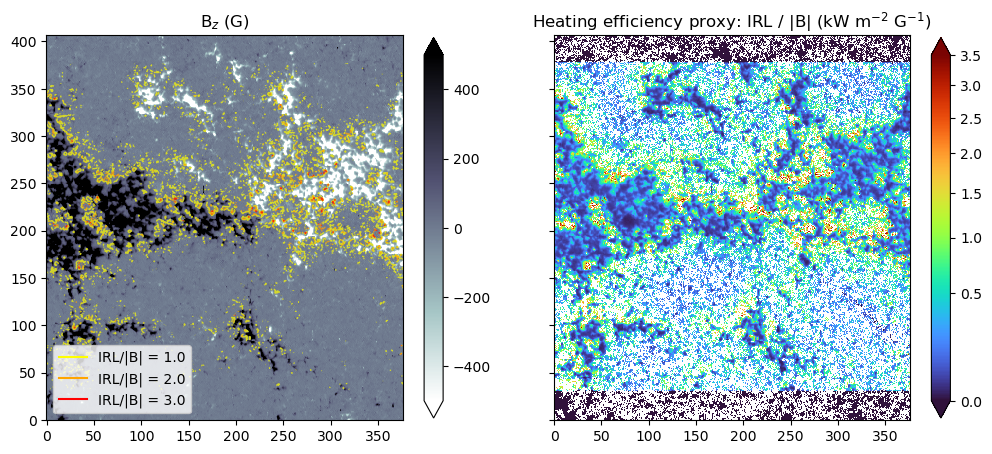

In [140]:
colors2 = ['yellow', 'orange', 'red']
levels2 = [1., 2., 3.]
# convolved_B_signed = gaussian_filter(Bz_sim, sigma=(factor, factor))
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(12,5),sharex=True,sharey=True)
ax = ax.ravel()
im = ax[0].imshow(Bz, origin='lower', cmap='bone_r',interpolation='none',vmax=500,vmin=-500,)
ax[0].contour(heating_efficiency, levels=levels2, colors=colors2, 
           linewidths=1, alpha=0.7, origin='lower')
plt.colorbar(im,fraction=0.045,extend='both')
ax[0].set_title(r'B$_{z}$ (G)')
handles = [
    Line2D([], [], color=c, linewidth=1.5, label=fr'IRL/|B| = {lvl}')
    for lvl, c in zip(levels2, colors2)
]
ax[0].legend(handles=handles, loc='lower left', frameon=True,)

im = ax[1].imshow(heating_efficiency, origin='lower', cmap='turbo', norm=colors.PowerNorm(0.6,vmin=0,vmax=3.5), interpolation='none')
plt.colorbar(im,fraction=0.045,extend='both')
ax[1].set_title(r'Heating efficiency proxy: IRL / |B| (kW m$^{-2}$ G$^{-1}$)')
plt.savefig(os.path.join(os.environ['results_dir'],'Bz_and_high_heating_efficiency_contours.png'),dpi=300,bbox_inches='tight')


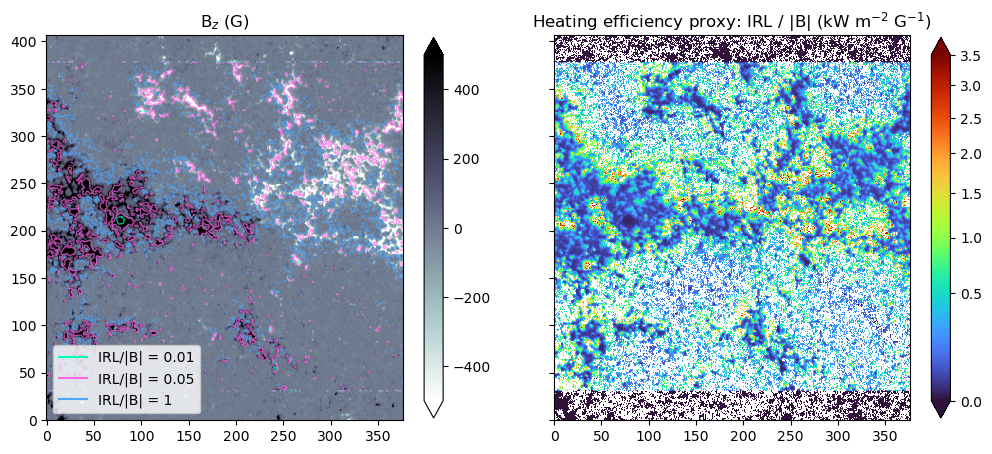

In [139]:
levels = [0.01, 0.05, 1]
colors1 =['#00FFB3', '#FF66E5', '#4DA6FF']
# convolved_B_signed = gaussian_filter(Bz_sim, sigma=(factor, factor))
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(12,5),sharex=True,sharey=True)
ax = ax.ravel()
im = ax[0].imshow(Bz, origin='lower', cmap='bone_r',interpolation='none',vmax=500,vmin=-500,)
ax[0].contour(heating_efficiency, levels=levels, colors=colors1, 
           linewidths=1, alpha=0.7, origin='lower')
plt.colorbar(im,fraction=0.045,extend='both')
ax[0].set_title(r'B$_{z}$ (G)')
handles = [
    Line2D([], [], color=c, linewidth=1.5, label=fr'IRL/|B| = {lvl}')
    for lvl, c in zip(levels, colors1)
]
ax[0].legend(handles=handles, loc='lower left', frameon=True,)

im = ax[1].imshow(heating_efficiency, origin='lower', cmap='turbo', norm=colors.PowerNorm(0.6,vmin=0,vmax=3.5), interpolation='none')
plt.colorbar(im,fraction=0.045,extend='both')
ax[1].set_title(r'Heating efficiency proxy: IRL / |B| (kW m$^{-2}$ G$^{-1}$)')
plt.savefig(os.path.join(os.environ['results_dir'],'Bz_and_low_heating_efficiency_contours.png'),dpi=300,bbox_inches='tight')
